# Notebook 3 - Identification: DAG and Causal Design

_First, please note that we layed out our DAG analysis and identification startegy after the data preparation and exploratory data analysis steps to reflect the order followed in our work, which first required familiarizing ourselves with the data before considering how different variables could be linked through causal or confounding dynamics._

The Exploratory Data Analysis in Notebook 2 established two important facts:
- insulin patients and non-insulin patients are systematically different on many variables that also predict readmission,
- readmission rates vary substantially across patient subgroups based on specific characteritics

These facts raise two questions that descriptive statistics alone cannot answer:
1) Is the association between insulin and readmission causal, or is it entirely explained by the fact that sicker patients receive insulin and are also more likely to be readmitted? $\rightarrow$ this reflects the issue of confounding variables
2) If there is a causal effect, does it vary across patient types? $\rightarrow$ this motivates the heterogenous treatment effects analysis we will be conducting later on

Before we actually start estimating anything, we need to answer a more fundamental question: **under what assumptions can we interpret the statistical relationship between insulin prescription and 30-day readmission as causal?** We will attempt to answer this question in three steps:
- **Step 1 - Covariate selection:** we will formally determine which variables should be included in the covariate set. This is the most involved step as it requires thinking through the potential timing of medical decisions and measurements, which ultimately impact causality.
- **Step 2 - DAG:** we will then draw a Directed Acyclic Graph (DAG) tha encodes our assumptions about the causal structure of the problem, making explicit which variables cause which other variables, where the confounding effects may come for, and what the main identification threats are
- **Step 3 - Identification assumptions:** state our main assumptions (unconfoundedness, overlap in propensity scores, and SUTVA)

## Step 1: Covariate selection

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import networkx as nx
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

project_folder_path = Path("..")
data_folder_path = project_folder_path / "data"
df = pd.read_csv(data_folder_path / "analysis_data.csv")

print(f"Analytic sample: {len(df):,} patients")
print(f"Total variables: {df.shape[1]}")

Analytic sample: 67,315 patients
Total variables: 75


### **Step 1-A. Reframing the long list of variables**

We start by listing all 75 variables in the dataset and grouping them by what they represent. This is the starting point before any causal reasoning.

Our dataset has three types of variables:
- **Outcome** - 30 day readmission
- **Treatment** - insulin treatment (3 variables which cover 3 ways insulin was administered)
- **Covariates** - everything else, used to control for confounding

For the covariates, we group them in a way that will 
inform our DAG analysis and identification strategy:

1. **Demographics** (`age_numeric`, `female`, race dummies): these capture 
   relatively stable patient characteristics that affect 
   both who receives insulin and who gets readmitted. 
   From the EDA, younger patients receive insulin more 
   frequently while older patients are readmitted more 
   often, making age a key heterogeneity dimension.

2. **Prior utilisation** (`number_outpatient`, 
   `number_emergency`, `number_inpatient`): as shown 
   in the EDA, a higher number of prior hospitalisations 
   is a very strong predictor of readmission in the 
   dataset. These variables capture chronic disease 
   burden and healthcare engagement before the current 
   admission.

3. **Admission context** (`admission_type_*`, 
   `admission_source_*`, `payer_*`, `specialty_*`): 
   medical specialty matters because different 
   specialties prescribe insulin at very different 
   rates. Payer type matters because Medicare patients 
   are older and sicker on average and hospitals face 
   direct financial penalties for Medicare readmissions, which is central to our research 
   question. Admission type and source proxy the urgency 
   and severity of the patient's condition at arrival.

4. **Baseline diagnosis** (`diag_*`, 
   `primary_diag_diabetes`): captures what the patient 
   was admitted for, basically whether they have diabetes as a 
   primary or secondary condition, and what other 
   conditions are present. Primary diagnosis affects 
   both prescribing decisions and readmission risk.

5. **Within-stay severity signals** (`time_in_hospital`, 
   `num_lab_procedures`, `num_procedures`, 
   `num_medications`, `number_diagnoses`): captures the 
   intensity of the hospitalisation itself. For example, from EDA insulin patients have significantly higher 
   medication counts and longer stays, reflecting 
   greater clinical complexity.

6. **Lab test results** (`A1C_tested`, `A1C_abnormal`, 
   `glu_tested`, `glu_abnormal`): captures whether A1C 
   and glucose tests were conducted and whether results 
   were abnormal. Abnormal A1C is a direct clinical 
   signal for insulin prescribing as it has had an SMD of 
   0.24 in the EDA.

7. **Medication management** (`med_change`, 
   `any_non_insulin_meds`): captures whether 
   medications were actively changed during the stay (making it a proxy for care intensity), and whether the 
   patient received any oral diabetes drugs alongside 
   or instead of insulin.

8. **Individual oral drug dummies** (`metformin_binary`,
   `glipizide_binary`, `glyburide_binary` and 19 
   others): captures which specific oral diabetes 
   medications were prescribed. Among these, metformin 
   is by far the most common (21%), followed by 
   glipizide (13%) and glyburide (11%). Most other 
   drugs have near-zero prescription rates.

In [17]:
all_vars = {
    "Outcome": [
        "readmitted_30",
    ],
    "Treatment": [
        "insulin_any",
        "insulin_steady_only",
        "insulin_up_only",
        "treatment_multivalued",
    ],
    "Demographics": [
        "age_numeric", "female", "weight_observed",
        "race_AfricanAmerican", "race_Hispanic",
        "race_Asian", "race_Other", "race_Unknown",
    ],
    "Prior utilisation": [
        "number_outpatient", "number_emergency",
        "number_inpatient",
    ],
    "Admission context": [
        "admission_type_Urgent", "admission_type_Elective",
        "admission_type_Other",
        "admission_source_Referral", "admission_source_Transfer",
        "admission_source_Other",
    ],
    "Payer and provider context": [
        "payer_HM", "payer_BC", "payer_Other", "payer_Unknown",
        "specialty_Family/GeneralPractice",
        "specialty_Emergency/Trauma", "specialty_Cardiology",
        "specialty_Surgery-General", "specialty_Other",
        "specialty_Unknown",
    ],
    "Baseline diagnosis": [
        "diag_circulatory", "diag_respiratory",
        "diag_digestive", "diag_diabetes", "diag_injury",
        "diag_musculoskeletal", "diag_genitourinary",
        "diag_neoplasms", "diag_other",
        "primary_diag_diabetes",
    ],
    "Within-stay severity signals": [
        "time_in_hospital", "num_lab_procedures",
        "num_procedures", "num_medications",
        "number_diagnoses",
    ],
    "Lab test results": [
        "A1C_tested", "A1C_abnormal",
        "glu_tested", "glu_abnormal",
    ],
    "Medication management": [
        "med_change", "any_non_insulin_meds",
    ],
    "Individual oral drug dummies": [
        "metformin_binary", "repaglinide_binary",
        "nateglinide_binary", "chlorpropamide_binary",
        "glimepiride_binary", "acetohexamide_binary",
        "glipizide_binary", "glyburide_binary",
        "tolbutamide_binary", "pioglitazone_binary",
        "rosiglitazone_binary", "acarbose_binary",
        "miglitol_binary", "troglitazone_binary",
        "tolazamide_binary", "examide_binary",
        "citoglipton_binary", "glyburide-metformin_binary",
        "glipizide-metformin_binary",
        "glimepiride-pioglitazone_binary",
        "metformin-rosiglitazone_binary",
        "metformin-pioglitazone_binary",
    ],
}

print("=" * 55)
total = 0
for group, vars in all_vars.items():
    print(f"{group} ({len(vars)})")
    for v in vars:
        print(f"  - {v}")
    total += len(vars)
    print()
print("=" * 55)
print(f"Total: {total} variables")

Outcome (1)
  - readmitted_30

Treatment (4)
  - insulin_any
  - insulin_steady_only
  - insulin_up_only
  - treatment_multivalued

Demographics (8)
  - age_numeric
  - female
  - weight_observed
  - race_AfricanAmerican
  - race_Hispanic
  - race_Asian
  - race_Other
  - race_Unknown

Prior utilisation (3)
  - number_outpatient
  - number_emergency
  - number_inpatient

Admission context (6)
  - admission_type_Urgent
  - admission_type_Elective
  - admission_type_Other
  - admission_source_Referral
  - admission_source_Transfer
  - admission_source_Other

Payer and provider context (10)
  - payer_HM
  - payer_BC
  - payer_Other
  - payer_Unknown
  - specialty_Family/GeneralPractice
  - specialty_Emergency/Trauma
  - specialty_Cardiology
  - specialty_Surgery-General
  - specialty_Other
  - specialty_Unknown

Baseline diagnosis (10)
  - diag_circulatory
  - diag_respiratory
  - diag_digestive
  - diag_diabetes
  - diag_injury
  - diag_musculoskeletal
  - diag_genitourinary
  - diag_neo

### **Step 1-B. Timing of medical decisions**

To actually figure out causal pathways between variables, we can ask ourselves about the timing of the healthcare circuit: **Was this variable plausibly known before treatment assignment, and can thus be a confounder, or could it already sit on the treatment pathway and thus reflect a treatment outcome?**

We should also consider that some variables are too close to the treatment variable we are dealing with, which make them bad control variables which should be excluded.

We therefore classify all covariate groups by timing:
- **Pre-tretment:** these are variables determined before or at the moment of admission, independently of what happens during the stay. These maybe be confounders in the analysis.
- **Time-ambiguous:** these variables are measured potentially during the stay and can thus be directly affected by treatment with insulin. The main issue here is thta timing is not clear (we don't know if lab analyses were conducted before or after insulin was administered). It might then be better to only include them for sensitivity checks.
- **Excluded variables:** these are essentially the bad controls which are variants or the treatment

We detail the way each variable was classified below:
##### **B.1 Pre-tretment variables** 
These variables were all determined before 
or at the moment of admission. These include the patient's age, 
gender, race, prior hospitalisation history, how they 
arrived, who their payer is, which specialty is treating 
them, and their primary diagnosis. None of these can be 
caused by the insulin decision made during the stay. 

Essentially, since none of these variables can be caused by the 
insulin decisiont, they are valid pre-treatment 
confounders: they affect both who receives insulin 
and who gets readmitted, creating the backdoor paths 
we need to block. **Conditioning on them in the causal 
model allows us to isolate the direct effect of insulin 
on readmission from the confounding that flows through 
these variables.** This is the selection on observables 
assumption: once we condition on this core set, we 
assume that remaining variation in insulin assignment 
is as good as random.

These form our **core adjustment set** for the main 
specification and the ones we will be using for our DAG analysis and identification strategy.

List:
- **Demographics** (`age_numeric`, `female`, 
`weight_observed`, `race_AfricanAmerican`, 
`race_Hispanic`, `race_Asian`, `race_Other`, 
`race_Unknown`): fixed patient characteristics 
determined before admission.
- **Prior utilisation** (`number_outpatient`, 
`number_emergency`, `number_inpatient`): all refer to 
visits and encounters that occurred before the current 
admission. 
- **Admission context** (`admission_type_Urgent`, 
`admission_type_Elective`, `admission_type_Other`, 
`admission_source_Referral`, `admission_source_Transfer`, 
`admission_source_Other`): how and where the patient entered the hospital.
- **Payer and provider context** (`payer_HM`, `payer_BC`, 
`payer_Other`, `payer_Unknown`, 
`specialty_Family/GeneralPractice`, 
`specialty_Emergency/Trauma`, `specialty_Cardiology`, 
`specialty_Surgery-General`, `specialty_Other`, 
`specialty_Unknown`): known at admission 
- **Baseline diagnosis** (`diag_circulatory`, 
`diag_respiratory`, `diag_digestive`, `diag_diabetes`, 
`diag_injury`, `diag_musculoskeletal`, 
`diag_genitourinary`, `diag_neoplasms`, `diag_other`, 
`primary_diag_diabetes`): the patient's diagnosis profile 
recorded at admission, reflecting their condition before 
any treatment decisions are made during the stay.



##### **B.2 Time-ambiguous variables** 
These variables were potentially measured during 
the stay. Time in hospital, number of medications, lab 
procedures, A1C and glucose test results, and medication 
changes all reflect what happened during the admission. **The issue here is that these will reflect the clinical response to insulin 
prescribing**, and thus bias the causal pathway if we control for them. We will not include them in the main specification but we will consider including them in the 
extended sensitivity specification.

List:
- **Within-stay severity signals** (`time_in_hospital`, 
`num_lab_procedures`, `num_procedures`, `num_medications`, 
`number_diagnoses`): these capture the intensity and 
complexity of the current hospitalisation. While they are 
strong proxies for patient severity, they reflect what 
happened during the entire stay. If a patient receives 
insulin and their condition worsens, they may stay longer 
and require more procedures and medications. Conditioning 
on these variables would risk blocking part of the causal 
effect of insulin on readmission.
- **Lab test results** (`A1C_tested`, `A1C_abnormal`, 
`glu_tested`, `glu_abnormal`): these capture whether A1C 
and glucose tests were conducted during the stay and 
whether results were abnormal. While abnormal A1C is a 
direct clinical signal for insulin prescribing, the test 
may have been ordered after the initial insulin decision 
was made, for example as a monitoring tool during the 
stay rather than as a trigger for the prescribing decision. The timing is ambiguous and may bias the analysis, so they will be included in the sensitivity checks instead.
- **`any_non_insulin_meds`**: captures whether the patient 
received any oral diabetes drug during the stay. As with 
the individual drug dummies, this prescribing decision 
may be simultaneous with or subsequent to the insulin 
decision rather than strictly prior to it.

##### **B.3 Excluded variables** 
Some variables must be excluded entirely from both the 
main specification and the sensitivity analysis. These 
are essentuially bad controls that 
would bias the estimate if included regardless of when 
they were measured. They correspond to a variation of treatment or they consistute a collider variable.

List:
- **Alternative treatment encodings** (`insulin_steady_only`, 
`insulin_up_only`, `treatment_multivalued`): these are 
simply different ways of encoding the same treatment 
decision as `insulin_any`. Including them as covariates 
when `insulin_any` is the treatment would introduce 
perfect or near-perfect collinearity.
- **`med_change`**: medication changes during the stay are 
part of the same clinical decision bundle as insulin 
prescribing. A physician deciding to prescribe insulin 
will simultaneously adjust other medications. Including 
it as a control would risk blocking part of the causal 
pathway we are trying to measure.
- **Individual oral drug dummies** (`metformin_binary`, 
`glipizide_binary`, `glyburide_binary` and 19 others): 
these represent prescribing decisions made as part of 
the same clinical bundle as insulin. Including them 
individually would introduce _near-collinearity_ and 
_overfit the propensity model_ without adding meaningful 
causal information. The clinically relevant information is already captured by `any_non_insulin_meds` in the 
timing-ambiguous set.
- **`discharge_disposition_id`**: excluded during data 
preparation as a post-treatment collider. It is caused 
by both treatment and outcome, and conditioning on it 
would open a spurious backdoor path. It does not appear 
in the analytic dataset.
- **Variables referring to patients not meaningfully "at risk" for the readmission process**: these were excluded in the data preparation process
- **`weight_observed`** is also excluded due to the fact that it can signify the severity of the patient's condition during the stay.

### **Step 1-C. Propensity Score Overlap Plot**

Before drawing the DAG, we run a practical check: given 
our core pre-treatment adjustment set, do treated and 
untreated patients overlap enough for causal comparison 
to be credible? This step will essentially allow us to **validate the choice of covariates.**

The propensity score is the estimated probability of 
receiving insulin given a patient's observed 
characteristics $$P(D=1|X).$$ If treated and untreated 
patients have completely non-overlapping propensity 
score distributions, no estimator can recover a credible 
causal effect, because there are no comparable patients 
on the other side to compare against.

Core adjustment set: 36 variables


Propensity score AUC: 0.621


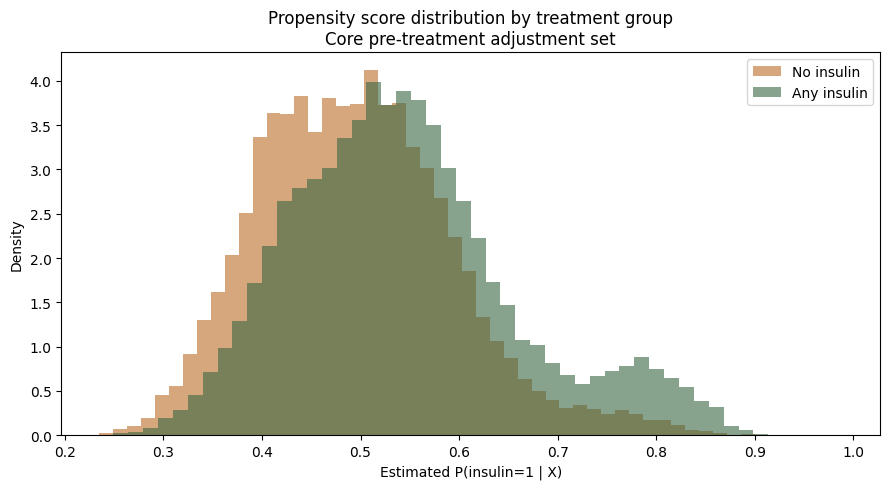

In [18]:
# Core pre-treatment adjustment set
core_vars = [
    # Demographics
    "age_numeric", "female",
    "race_AfricanAmerican", "race_Hispanic",
    "race_Asian", "race_Other", "race_Unknown",
    # Prior utilisation
    "number_outpatient", "number_emergency",
    "number_inpatient",
    # Admission context
    "admission_type_Urgent", "admission_type_Elective",
    "admission_type_Other",
    "admission_source_Referral", "admission_source_Transfer",
    "admission_source_Other",
    # Payer and provider context
    "payer_HM", "payer_BC", "payer_Other", "payer_Unknown",
    "specialty_Family/GeneralPractice",
    "specialty_Emergency/Trauma", "specialty_Cardiology",
    "specialty_Surgery-General", "specialty_Other",
    "specialty_Unknown",
    # Baseline diagnosis
    "diag_circulatory", "diag_respiratory",
    "diag_digestive", "diag_diabetes", "diag_injury",
    "diag_musculoskeletal", "diag_genitourinary",
    "diag_neoplasms", "diag_other",
    "primary_diag_diabetes",
]

print(f"Core adjustment set: {len(core_vars)} variables")

# standardise and fit
X = StandardScaler().fit_transform(
    df[core_vars].fillna(0)
)
y = df["insulin_any"]

prop_model = LogisticRegression(
    penalty="l2", C=1.0,
    max_iter=2000, random_state=42
)
prop_model.fit(X, y)
propensity = prop_model.predict_proba(X)[:, 1]

prop_auc = roc_auc_score(y, propensity)
print(f"Propensity score AUC: {prop_auc:.3f}")

# plot
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(propensity[y==0], bins=50, alpha=0.6,
        color="#bc6c25", label="No insulin", density=True)
ax.hist(propensity[y==1], bins=50, alpha=0.6,
        color="#386641", label="Any insulin", density=True)

ax.set_title("Propensity score distribution by treatment group\n"
             "Core pre-treatment adjustment set")
ax.set_xlabel("Estimated P(insulin=1 | X)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()


The overlap plot shows the distribution of propensity 
scores for insulin patients (green) and non-insulin 
patients (orange).

Using the core pre-treatment adjustment set of 36 
variables, the two distributions overlap substantially 
across most of the propensity score range, both centred 
around 0.4–0.6. The propensity AUC of 0.621 indicates that our pre-treatment 
covariates explain a meaningful share of the variation 
in insulin assignment, enough to perform meaningful 
causal adjustment, but the treatment assignment is far 
from perfectly determined by observables alone. Treated 
and untreated patients remain comparable across a wide 
range of covariate profiles. **This confirms that with our covariates selection procedure, 
there exist for most patients comparable counterparts on the other side, making causal comparison credible.**

As a check, we see below that when we include all variables, the propensity AUC rises sharply to 0.881. This 
confirms that the timing-ambiguous within-stay variables (like medication counts, lab procedures, time in hospital, A1C results) and other treatment variants are highly predictive of insulin 
assignment, pushing propensity scores toward 0 and 1 
and leaving the two groups with little common support. Without our covariate choice procedure, causal comparison with Double ML would NOT be possible.

Full covariate set: 70 variables


Propensity AUC: 0.881


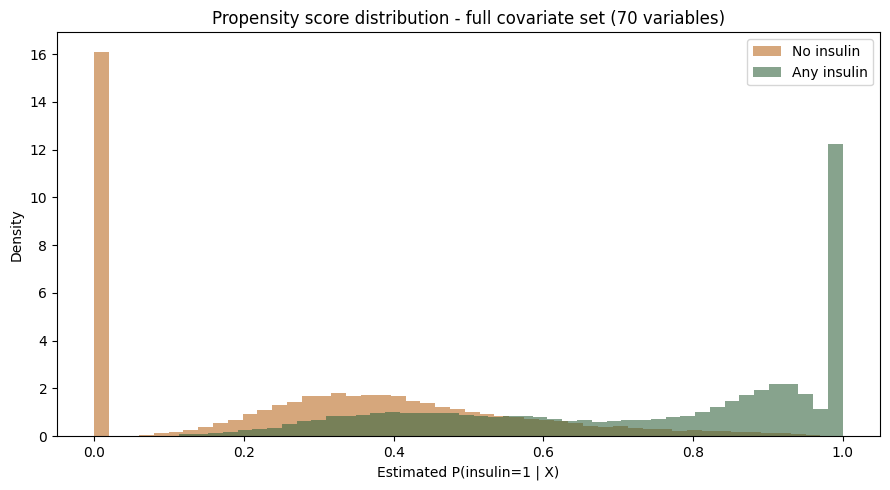

In [19]:
# check - all 70 covariates (no exclusions except outcome and treatment)
all_70_vars = [col for col in df.columns if col not in [
    "readmitted_30",
    "insulin_any", "insulin_steady_only",
    "insulin_up_only", "treatment_multivalued",
]]

print(f"Full covariate set: {len(all_70_vars)} variables")

X_all = StandardScaler().fit_transform(
    df[all_70_vars].fillna(0)
)

prop_model_all = LogisticRegression(
    penalty="l2", C=1.0,
    max_iter=2000, random_state=42
)
prop_model_all.fit(X_all, y)
propensity_all = prop_model_all.predict_proba(X_all)[:, 1]

prop_auc_all = roc_auc_score(y, propensity_all)
print(f"Propensity AUC: {prop_auc_all:.3f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(propensity_all[y==0], bins=50, alpha=0.6,
        color="#bc6c25", label="No insulin", density=True)
ax.hist(propensity_all[y==1], bins=50, alpha=0.6,
        color="#386641", label="Any insulin", density=True)
ax.set_title("Propensity score distribution - full covariate set (70 variables)")
ax.set_xlabel("Estimated P(insulin=1 | X)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()


## Step 2: DAG analysis

We can now draw a DAG encoding our assumptions about the causal structure of the problem.

Fundamentally, in this project, our research question cares about two things: readmssion after 30-days and treatment with insulin. Our problem is that the severity of a patient's condition (latent patient severity) drives these two variables. Typically, we can easily understand that:
- **Insulin assignment (treatment - D):** sicker patients receive insulin more often, while less severe cases may not receive medication at all according to this dataset
- **Readmission (outcome - Y):** sicker patients are more likely to be readmitted regardless of the course of treatment that they receive.

This creates a sort of backdoor path: $$D \leftarrow \text{Severity} \rightarrow Y$$

Because severity is unobserved, we cannot block this path directly by conditioning on it. Instead, we block it indirectly by conditioning on observed variables that proxy severity. These will be the core pre-treatment variable groups identified earlier. The rest is excluded as their position in the causal graph is ambiguous. 

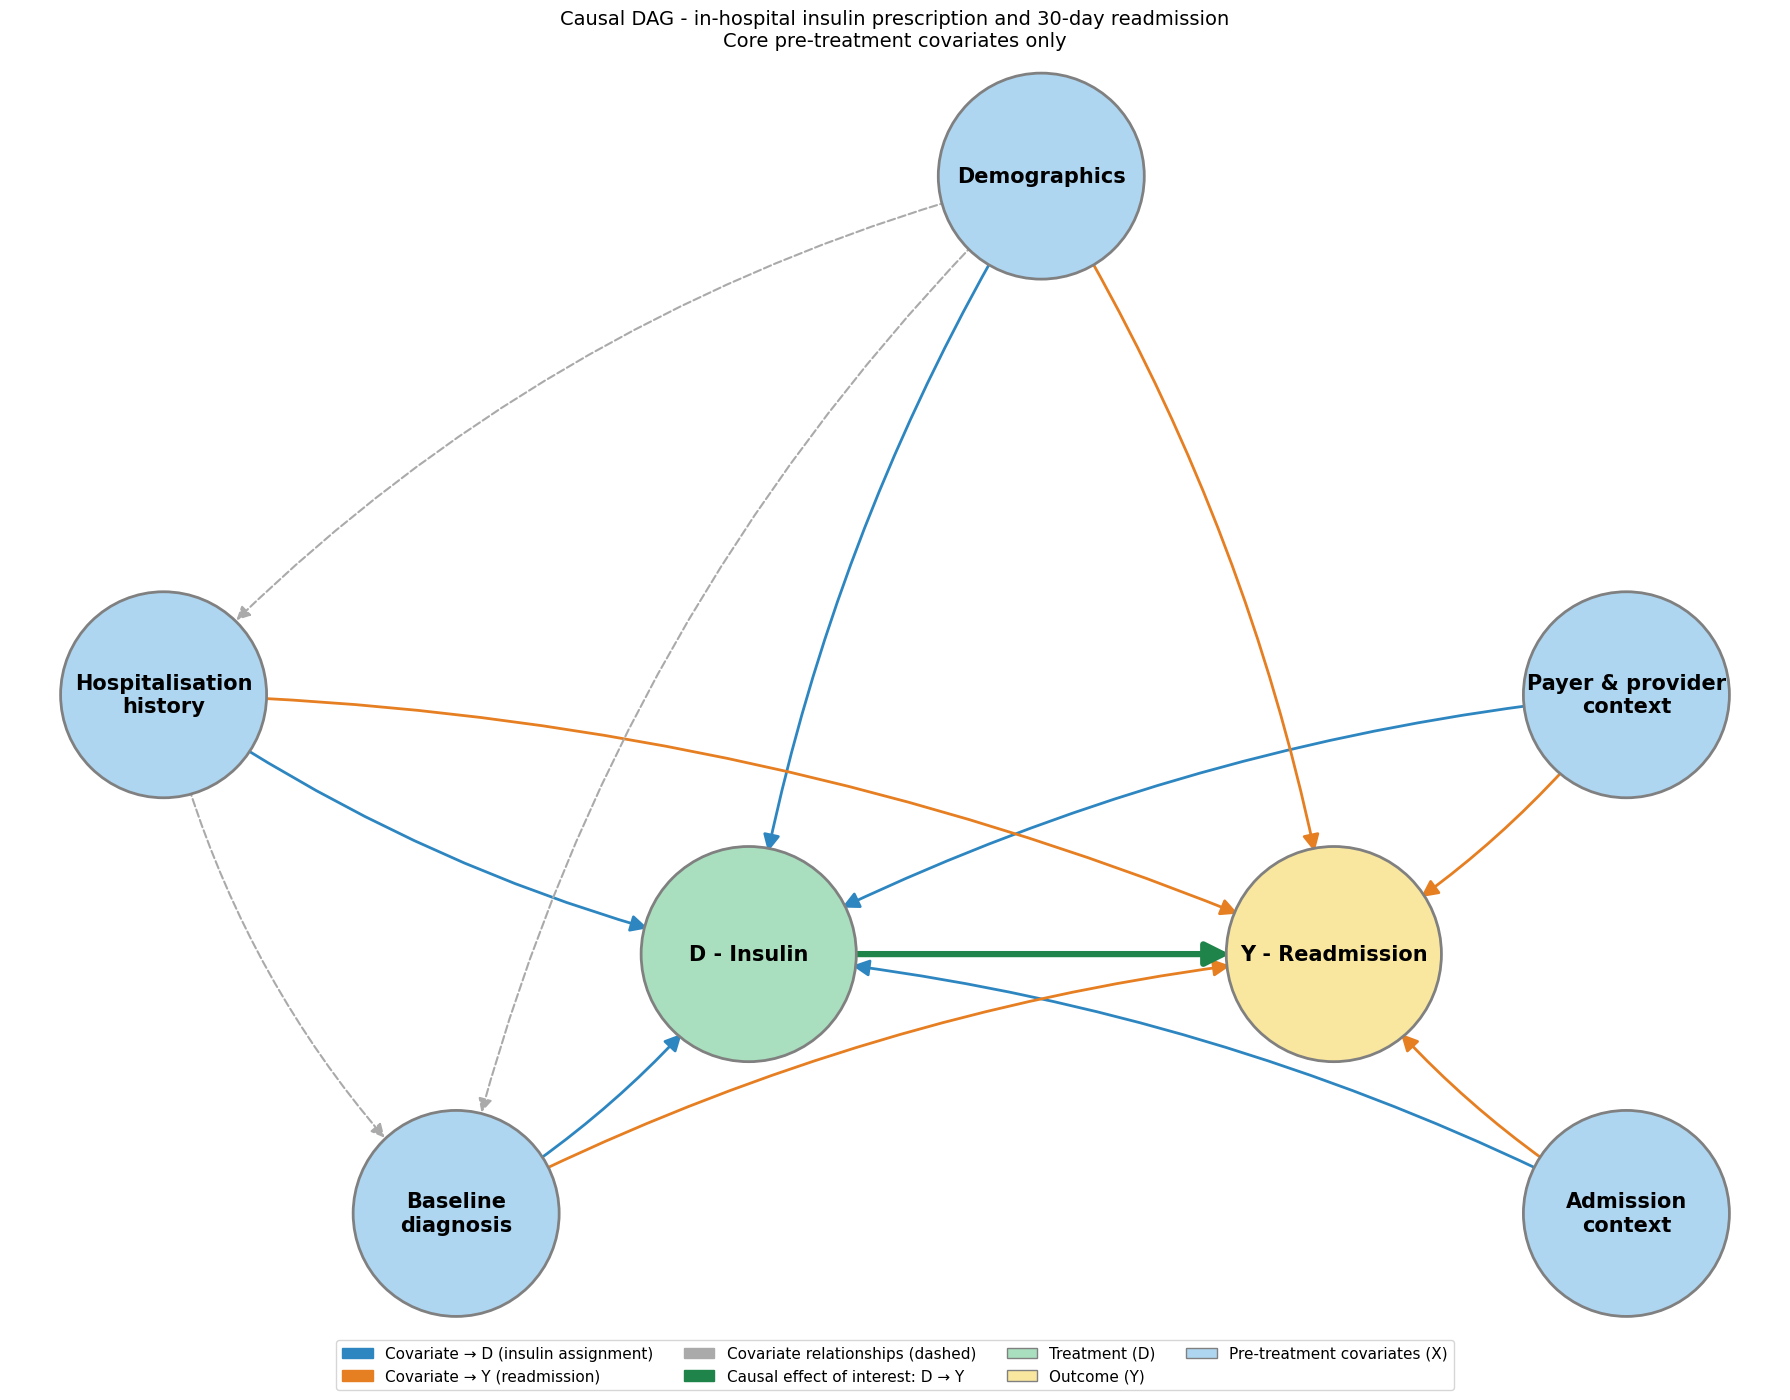

In [20]:
G = nx.DiGraph()

nodes = [
    "Demographics",
    "Hospitalisation\nhistory",
    "Admission\ncontext",
    "Payer & provider\ncontext",
    "Baseline\ndiagnosis",
    "D - Insulin",
    "Y - Readmission",
]

G.add_nodes_from(nodes)

edges = {
    "covariate": [
        ("Demographics",             "D - Insulin"),
        ("Demographics",             "Y - Readmission"),
        ("Demographics",             "Hospitalisation\nhistory"),
        ("Demographics",             "Baseline\ndiagnosis"),
        ("Hospitalisation\nhistory",  "Baseline\ndiagnosis"),
        ("Hospitalisation\nhistory",  "Y - Readmission"),
        ("Hospitalisation\nhistory",  "D - Insulin"),
        ("Baseline\ndiagnosis",       "D - Insulin"),
        ("Baseline\ndiagnosis",       "Y - Readmission"),
        ("Admission\ncontext",        "D - Insulin"),
        ("Admission\ncontext",        "Y - Readmission"),
        ("Payer & provider\ncontext", "D - Insulin"),
        ("Payer & provider\ncontext", "Y - Readmission"),
    ],
    "causal": [
        ("D - Insulin", "Y - Readmission"),
    ],
}

for etype, edge_list in edges.items():
    for src, dst in edge_list:
        G.add_edge(src, dst, etype=etype)

# D and Y in centre, covariates around them
pos = {
    "Demographics":             ( 0,    6),
    "Hospitalisation\nhistory":  (-6,   2),
    "Baseline\ndiagnosis":      (-4,  -2),
    "Payer & provider\ncontext": ( 4,   2),
    "Admission\ncontext":      ( 4,  -2),
    "D - Insulin":              (-2,   0),
    "Y - Readmission":          ( 2,   0),
}

node_color_map = {
    "Demographics":             "#aed6f1",
    "Hospitalisation\nhistory":  "#aed6f1",
    "Admission\ncontext":       "#aed6f1",
    "Payer & provider\ncontext":"#aed6f1",
    "Baseline\ndiagnosis":      "#aed6f1",
    "D - Insulin":              "#a9dfbf",
    "Y - Readmission":          "#f9e79f",
}
node_colors_list = [node_color_map[n] for n in G.nodes()]
node_sizes = [
    24000 if n in ("D - Insulin", "Y - Readmission")
    else 22000
    for n in G.nodes()
]

fig, ax = plt.subplots(figsize=(18, 14))

nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors_list,
    node_size=node_sizes,
    edgecolors="grey",
    linewidths=2,
    ax=ax
)

nx.draw_networkx_labels(
    G, pos,
    font_size=15,
    font_weight="bold",
    ax=ax
)

# Covariate → D
cov_to_d = [(u, v) for u, v, d in G.edges(data=True)
            if d["etype"] == "covariate" and v == "D - Insulin"]
nx.draw_networkx_edges(
    G, pos,
    edgelist=cov_to_d,
    edge_color="#2e86c1",
    width=2,
    arrows=True,
    arrowsize=25,
    arrowstyle="-|>",
    connectionstyle="arc3,rad=0.1",
    ax=ax,
    min_source_margin=70,
    min_target_margin=75,
)

# Covariate → Y
cov_to_y = [(u, v) for u, v, d in G.edges(data=True)
            if d["etype"] == "covariate" and v == "Y - Readmission"]
nx.draw_networkx_edges(
    G, pos,
    edgelist=cov_to_y,
    edge_color="#e67e22",
    width=2,
    arrows=True,
    arrowsize=25,
    arrowstyle="-|>",
    connectionstyle="arc3,rad=-0.1",
    ax=ax,
    min_source_margin=70,
    min_target_margin=75,
)

# Covariate → covariate
cov_to_cov = [(u, v) for u, v, d in G.edges(data=True)
              if d["etype"] == "covariate"
              and v not in ("D - Insulin", "Y - Readmission")]
nx.draw_networkx_edges(
    G, pos,
    edgelist=cov_to_cov,
    edge_color="#aaaaaa",
    width=1.5,
    arrows=True,
    arrowsize=20,
    arrowstyle="-|>",
    connectionstyle="arc3,rad=0.15",
    style="dashed",
    ax=ax,
    min_source_margin=70,
    min_target_margin=75,
)

# Causal D → Y
causal_edges = [(u, v) for u, v, d in G.edges(data=True)
                if d["etype"] == "causal"]
nx.draw_networkx_edges(
    G, pos,
    edgelist=causal_edges,
    edge_color="#1e8449",
    width=4.5,
    arrows=True,
    arrowsize=35,
    arrowstyle="-|>",
    connectionstyle="arc3,rad=0.0",
    ax=ax,
    min_source_margin=70,
    min_target_margin=75,
)

legend_elements = [
    mpatches.Patch(color="#2e86c1",
                   label="Covariate → D (insulin assignment)"),
    mpatches.Patch(color="#e67e22",
                   label="Covariate → Y (readmission)"),
    mpatches.Patch(color="#aaaaaa",
                   label="Covariate relationships (dashed)"),
    mpatches.Patch(color="#1e8449",
                   label="Causal effect of interest: D → Y"),
    mpatches.Patch(facecolor="#a9dfbf", edgecolor="grey",
                   label="Treatment (D)"),
    mpatches.Patch(facecolor="#f9e79f", edgecolor="grey",
                   label="Outcome (Y)"),
    mpatches.Patch(facecolor="#aed6f1", edgecolor="grey",
                   label="Pre-treatment covariates (X)"),
]
ax.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=4,
    fontsize=11,
    bbox_to_anchor=(0.5, -0.06)
)
ax.set_title(
    "Causal DAG - in-hospital insulin prescription "
    "and 30-day readmission\n"
    "Core pre-treatment covariates only",
    fontsize=14, pad=15
)
ax.axis("off")
plt.tight_layout()
plt.show()

## Step 3: Identification Assumptions

In the following notebook, we use Double Machine Learning 
to estimate the causal effect of insulin prescription on 
30-day readmission. Before estimating anything, we evaluate three assumptions required for this estimate to have 
a causal interpretation.

### Assumption 1 - Unconfoundedness

$$Y(1), Y(0) \perp D \mid X$$

Conditional on our core pre-treatment covariates X, 
insulin assignment is as good as random. This is the 
central assumption. 

**Defence:** our 37 pre-treatment variables cover all 
major observable dimensions of patient severity at 
admission. The propensity AUC of 0.636 confirms 
meaningful but imperfect predictability of treatment 
from observables.

**Main threat:** unobserved physician judgment. A 
substantial share of the prescribing decision is driven 
by bedside clinical assessment that is never recorded 
in administrative data. This is the primary limitation 
of our identification strategy.

--- 

### Assumption 2 - Overlap

$$0 < P(D=1 \mid X) < 1 \quad \text{for all } X$$

Every patient must have a positive probability of 
receiving or not receiving insulin given their 
characteristics.

**Defence:** the propensity score overlap plot in 
Step 2 showed significant overlap which confirms this.

---

### Assumption 3 - SUTVA

Two conditions must hold:

**No interference:** one patient's insulin prescription 
does not affect another patient's readmission. This is 
plausible because there is no mechanism through which one 
patient's treatment affects another's outcome.

**Treatment well-defined:** our primary treatment 
`insulin_any` equals 1 if the patient received any 
insulin during the stay, 0 otherwise. This pools 
Steady, Up, and Down doses, which are three clinically distinct 
decisions. We accept this limitation for the main 
analysis and test robustness to this choice in 
the sensitivity analysis by disaggregating this variable and using alternative 
treatment definitions.